In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("../Data/Medical_appointment_data.csv")

In [3]:
df.shape

(109593, 26)

In [4]:
df.columns

Index(['specialty', 'appointment_time', 'gender', 'no_show', 'disability',
       'place', 'appointment_shift', 'age', 'under_12_years_old',
       'over_60_years_old', 'patient_needs_companion', 'average_temp_day',
       'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'rain_intensity', 'heat_intensity',
       'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism',
       'Handcap', 'Scholarship', 'SMS_received'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   str    
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  str    
 3   no_show                      109593 non-null  str    
 4   disability                   92992 non-null   str    
 5   place                        98054 non-null   str    
 6   appointment_shift            109593 non-null  str    
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             107348 non-null  float64
 13  max_temp_d

In [6]:
df.isnull().sum()

specialty                      20127
appointment_time                   0
gender                             0
no_show                            0
disability                     16601
place                          11539
appointment_shift                  0
age                            22960
under_12_years_old                 0
over_60_years_old                  0
patient_needs_companion            0
average_temp_day                2211
average_rain_day                2245
max_temp_day                    2227
max_rain_day                    2263
rainy_day_before                   0
storm_day_before                   0
rain_intensity                     0
heat_intensity                     0
appointment_date_continuous        0
Hipertension                       0
Diabetes                           0
Alcoholism                         0
Handcap                            0
Scholarship                        0
SMS_received                       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(36)

In [8]:
df.describe()

,appointment_time,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
count,109593.000000,86633.000000,109593.000000,109593.000000,109593.000000,107382.000000,107348.000000,107366.000000,107330.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000,109593.000000
mean,12.120966,18.632138,0.446424,0.071328,0.519823,20.346642,0.183537,24.032910,2.048093,0.937396,0.937533,0.058088,0.023952,0.018541,0.009116,0.055113,0.311808
std,3.281623,17.666999,0.497124,0.257372,0.499609,3.446079,0.416267,3.959696,4.352247,0.242251,0.242004,0.233910,0.152901,0.134899,0.095040,0.228202,0.463234
min,7.000000,2.000000,0.000000,0.000000,0.000000,8.940000,0.000000,13.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,8.000000,0.000000,0.000000,0.000000,18.060000,0.000000,21.400000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,13.000000,12.000000,0.000000,0.000000,1.000000,20.600000,0.010000,23.900000,0.200000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15.000000,18.000000,1.000000,0.000000,1.000000,22.720000,0.150000,26.800000,1.900000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,18.000000,110.000000,1.000000,1.000000,1.000000,28.010000,4.770000,35.400000,45.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.describe(include='object')

,specialty,gender,no_show,disability,place,appointment_shift,rain_intensity,heat_intensity,appointment_date_continuous
count,89466,109593,109593,92992,98054,109593,109593,109593,109593
unique,8,3,2,3,26289,2,4,5,498
top,psychotherapy,M,no,intellectual,ITAJAÍ,afternoon,no_rain,mild,2021-04-02
freq,28645,82269,74761,62852,20515,59334,76415,46903,1512


In [10]:
df["no_show"].value_counts()

no_show
no     74761
yes    34832
Name: count, dtype: int64

In [11]:
(df["no_show"].value_counts(normalize=True)*100).round(2)

no_show
no     68.22
yes    31.78
Name: proportion, dtype: float64

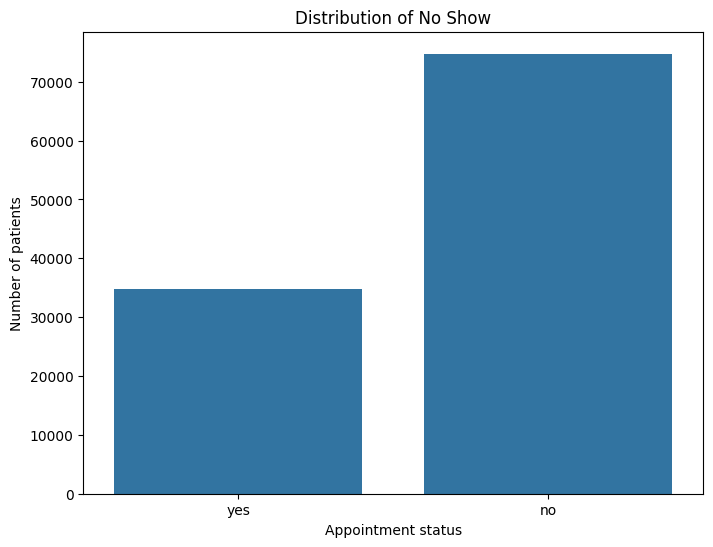

In [12]:
#UNIVARIATE ANALYSIS
plt.figure(figsize=(8,6))
sns.countplot(data=df,x="no_show")
plt.title("Distribution of No Show")
plt.xlabel("Appointment status")
plt.ylabel("Number of patients")
plt.show()

In [13]:
df["gender"].value_counts()
#"The dataset contains a third gender category
#  represented by I. Since the data dictionary is not
#  available, its exact meaning cannot be confirmed."

gender
M    82269
F    27077
I      247
Name: count, dtype: int64

In [14]:
(df['gender'].value_counts(normalize=True) * 100).round(2)

gender
M    75.07
F    24.71
I     0.23
Name: proportion, dtype: float64

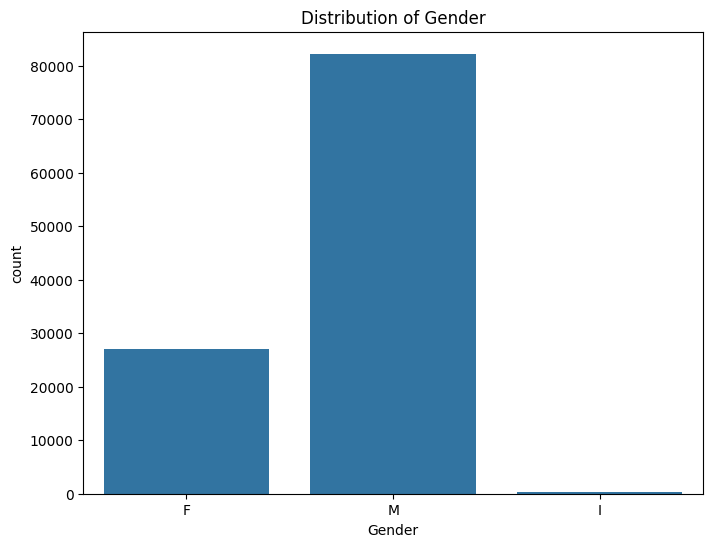

In [15]:
plt.figure(figsize=(8,6))
sns.countplot(data=df,x="gender")
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.show()
#The hospital dataset is dominated by male patients,
#  indicating that most appointments are booked by
#  male patients. However, this graph only shows the 
# distribution of gender. It does not indicate whether
#  gender affects appointment attendance. 
# That relationship will be analyzed later during
#  bivariate analysis.

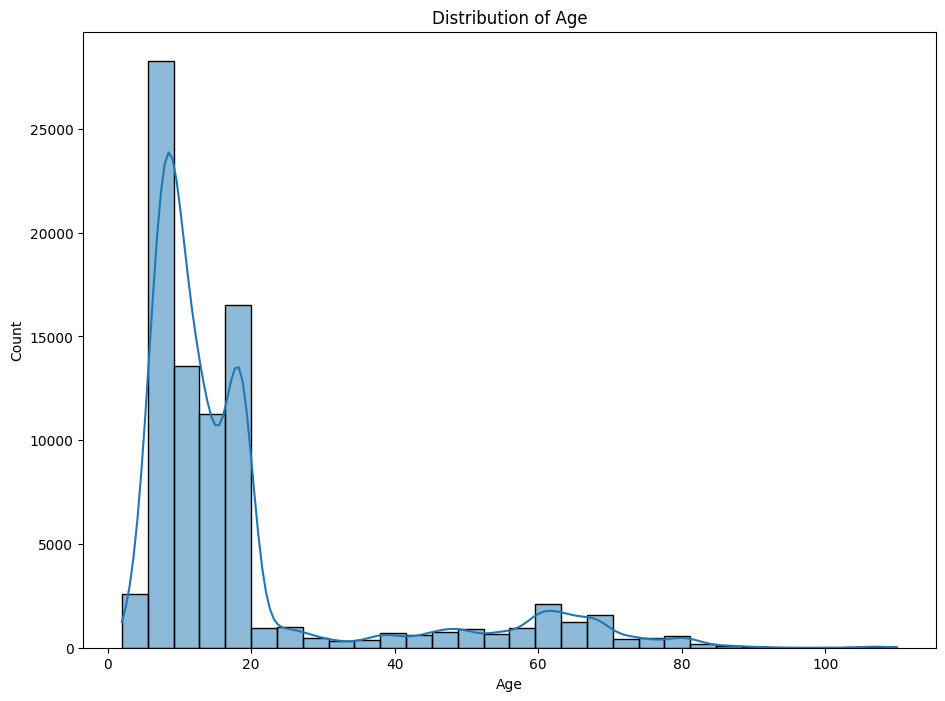

In [16]:
plt.figure(figsize=(11,8))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
#Most patients belong to the 5–20 years age group.
#As age increases, the number of patients decreases.
#The distribution is positively (right) skewed, 
# indicating that most patients are young while fewer 
# patients belong to higher age groups.

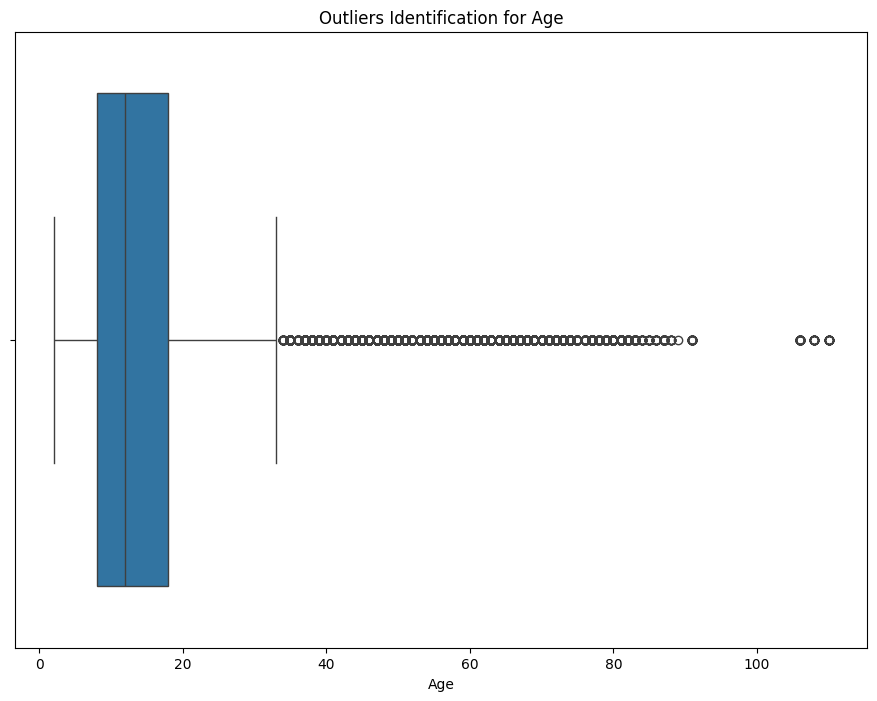

In [17]:
plt.figure(figsize=(11,8))
sns.boxplot(data=df , x= "age")
plt.title("Outliers Identification for Age")
plt.xlabel("Age")
plt.show()
#The detected outliers may represent genuine elderly 
# patients rather than incorrect data. Therefore, they 
# should not be removed without domain validation.

In [18]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
print("Q1:", Q1)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
#Although the IQR method classifies ages above 33 years
#  as outliers, these values are not necessarily incorrect
#  In a healthcare dataset, adults and elderly patients
#  are expected. Therefore, these observations should
#  be retained unless domain experts confirm they are
#  invalid.


Q1: 8.0
Q3: 18.0
IQR: 10.0
Lower Bound: -7.0
Upper Bound: 33.0


In [19]:
df['specialty'].value_counts()

specialty
psychotherapy           28645
speech therapy          22322
physiotherapy           21004
occupational therapy    11319
pedagogo                 3536
enf                      1681
assist                    635
sem especialidade         324
Name: count, dtype: int64

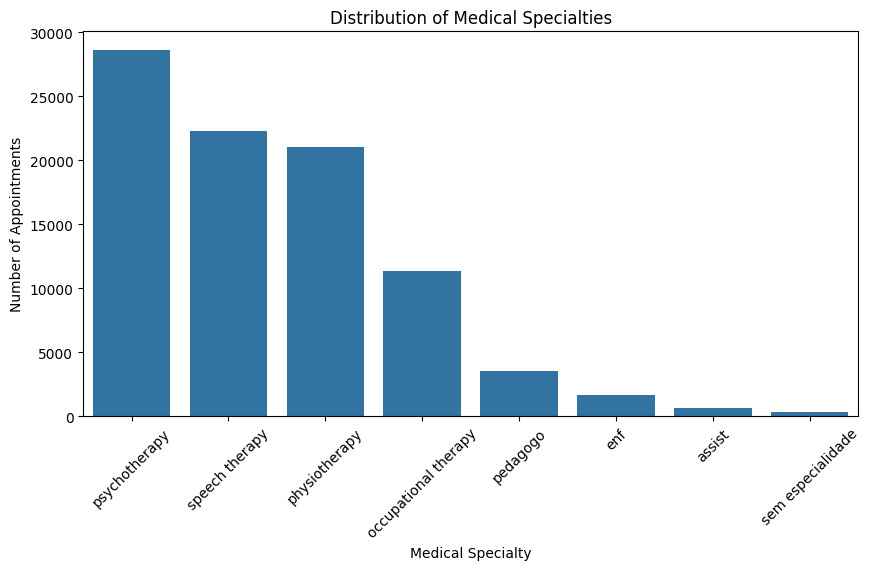

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="specialty",
    order=df["specialty"].value_counts().index
)

plt.title("Distribution of Medical Specialties")
plt.xlabel("Medical Specialty")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)

plt.show()
#The appointment distribution is not uniform across specialties.
# Some departments handle significantly more
#  appointments than others. However, this analysis only 
# shows appointment volume. Whether a particular 
# specialty has a higher no-show rate will be analyzed 
# during bivariate analysis.

In [21]:
df["appointment_shift"].value_counts()

appointment_shift
afternoon    59334
morning      50259
Name: count, dtype: int64

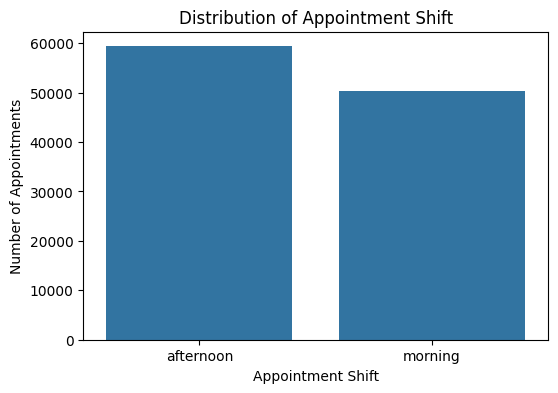

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="appointment_shift",
    order=df["appointment_shift"].value_counts().index
)

plt.title("Distribution of Appointment Shift")
plt.xlabel("Appointment Shift")
plt.ylabel("Number of Appointments")

plt.show()
#The hospital schedules appointments in both morning
#  and afternoon shifts, with a slightly higher
#  workload in the afternoon. This information can
#  help in planning doctor availability, staff allocation,
#  and hospital resources.

In [23]:
df["SMS_received"].value_counts()

SMS_received
0    75421
1    34172
Name: count, dtype: int64

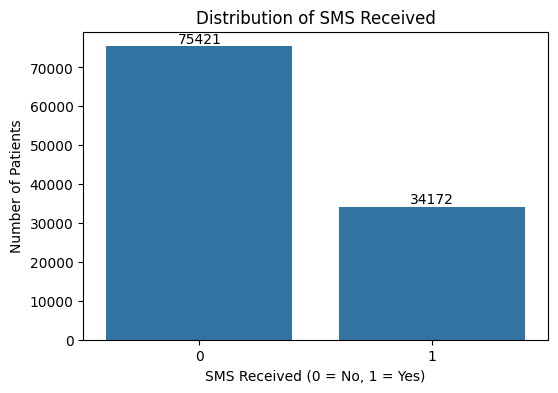

In [24]:
plt.figure(figsize=(6,4))
ax = sns.countplot(
    data=df,
    x="SMS_received"
)
plt.title("Distribution of SMS Received")
plt.xlabel("SMS Received (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)
plt.show()
#Most patients in the dataset did not receive appointment
#  reminder SMS messages. This indicates that reminder
#  messages were not sent to every patient. 
# The effectiveness of SMS reminders in reducing no-shows
#  will be evaluated during bivariate analysis.

In [25]:

binary_features = [
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'Scholarship'
]

for col in binary_features:
    print(f"\n{col}")
    print(df[col].value_counts())


Hipertension
Hipertension
0    103227
1      6366
Name: count, dtype: int64

Diabetes
Diabetes
0    106968
1      2625
Name: count, dtype: int64

Alcoholism
Alcoholism
0    107561
1      2032
Name: count, dtype: int64

Handcap
Handcap
0    108594
1       999
Name: count, dtype: int64

Scholarship
Scholarship
0    103553
1      6040
Name: count, dtype: int64


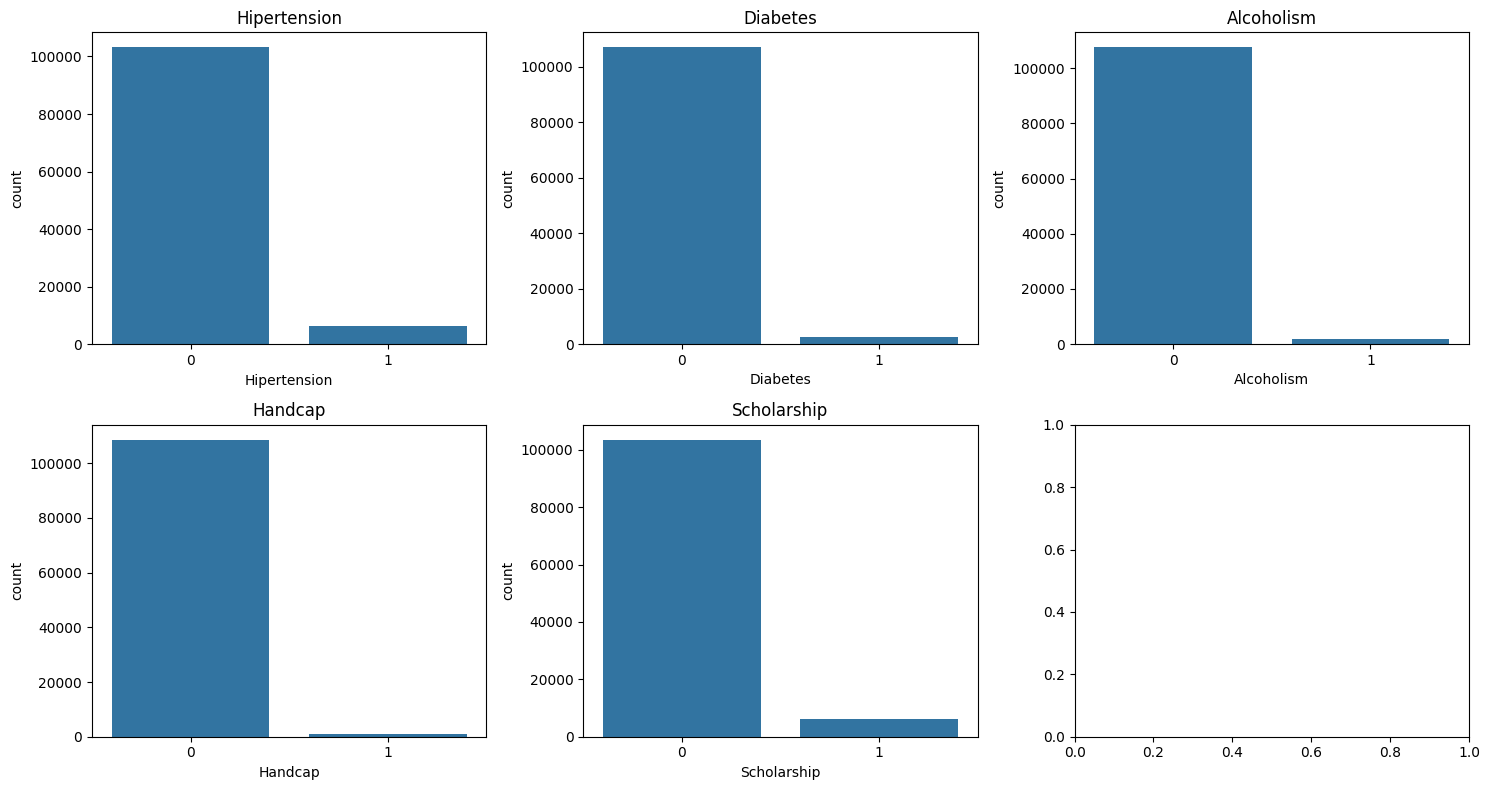

In [26]:
binary_features = [
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'Scholarship'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(binary_features):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [27]:
#The dataset is highly imbalanced for these health-related
#  features, as most patients belong to the 0 (No)
#  category. Although these conditions are less frequent,
#  they may still influence appointment attendance and 
# should be evaluated during bivariate analysis and model
#  training.

In [28]:
#BIVARIATE ANALYSIS
# Gender VS no_show
pd.crosstab(df["gender"],df["no_show"])

no_show,no,yes
gender,,
F,17955,9122
I,204,43
M,56602,25667


In [29]:
pd.crosstab(df["gender"],df["no_show"],normalize="index")*100

no_show,no,yes
gender,,
F,66.310891,33.689109
I,82.591093,17.408907
M,68.801128,31.198872


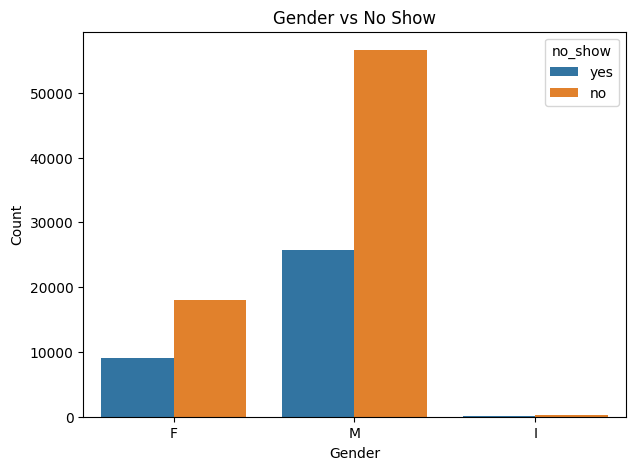

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue="no_show"
)

plt.title("Gender vs No Show")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [31]:
#The analysis shows that gender has only a weak relationship with 
# appointment attendance. Female patients have a slightly higher
#  no-show rate (33.69%) compared to male patients (31.20%),
#  but the difference is small. Therefore, gender alone is not a 
# strong predictor of patient no-shows and should be considered along 
# with other factors such as SMS reminders, age, specialty, and health
#  conditions.

In [32]:
# SMS RECIEVED VS NO SHOW
pd.crosstab(df["SMS_received"], df["no_show"])


no_show,no,yes
SMS_received,,
0,51474,23947
1,23287,10885


In [33]:
pd.crosstab(
    df["SMS_received"],
    df["no_show"],
    normalize="index"
) * 100

no_show,no,yes
SMS_received,,
0,68.248896,31.751104
1,68.146436,31.853564


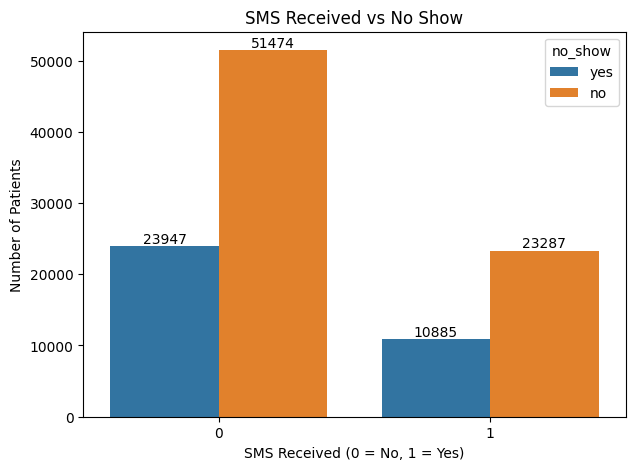

In [34]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="SMS_received",
    hue="no_show"
)

plt.title("SMS Received vs No Show")
plt.xlabel("SMS Received (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [35]:
#The analysis indicates that SMS_received has a very weak relationship
#  with appointment attendance. Based on the available data, 
# sending an SMS reminder did not significantly reduce the no-show rate.
#  However, this does not necessarily mean SMS reminders are ineffective 
# in general—other factors (such as who received the reminders, 
# reminder timing, or patient characteristics) may influence the outcome.


In [36]:
#AGE VS NO SHOW
df.groupby("no_show")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
no_show,,,,,,,,
no,59432.0,18.888629,18.577185,2.0,8.0,12.0,18.0,110.0
yes,27201.0,18.071725,15.478915,2.0,8.0,14.0,19.0,110.0


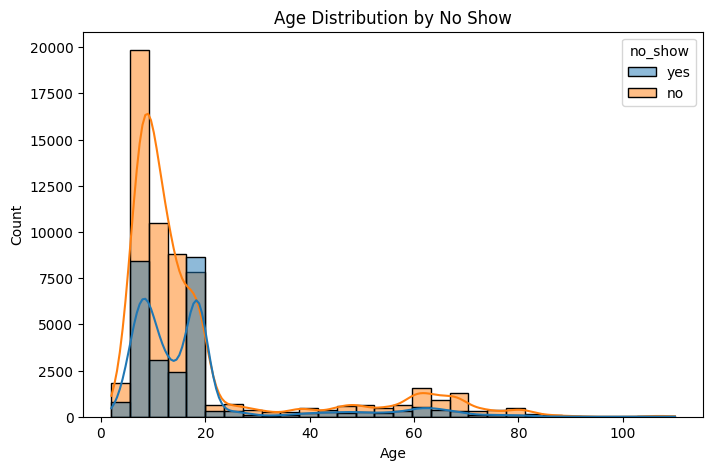

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    hue="no_show",
    bins=30,
    kde=True
)

plt.title("Age Distribution by No Show")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()
#The histogram also suggests that the age distribution is almost 
# the same for both groups, indicating that age alone may not strongly
#  influence appointment attendance.

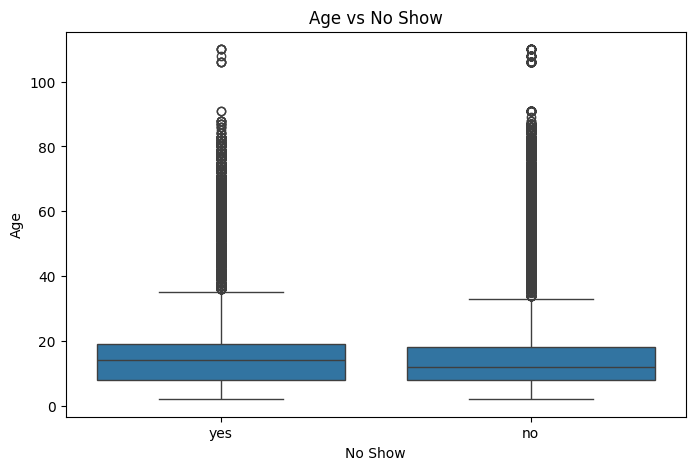

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="no_show",
    y="age"
)

plt.title("Age vs No Show")
plt.xlabel("No Show")
plt.ylabel("Age")

plt.show()
#The boxplot indicates that the age distributions of patients
#  who attended and those who missed their appointments are very similar.
#  There is no major visual difference between the two groups.

In [39]:
#Specialty vs No Show
pd.crosstab(df["specialty"], df["no_show"])

no_show,no,yes
specialty,,
assist,464,171
enf,1349,332
occupational therapy,8618,2701
pedagogo,2971,565
physiotherapy,13786,7218
psychotherapy,19382,9263
sem especialidade,153,171
speech therapy,16088,6234


In [40]:
pd.crosstab(
    df["specialty"],
    df["no_show"],
    normalize="index"
)*100

no_show,no,yes
specialty,,
assist,73.070866,26.929134
enf,80.249851,19.750149
occupational therapy,76.137468,23.862532
pedagogo,84.021493,15.978507
physiotherapy,65.635117,34.364883
psychotherapy,67.662768,32.337232
sem especialidade,47.222222,52.777778
speech therapy,72.072395,27.927605


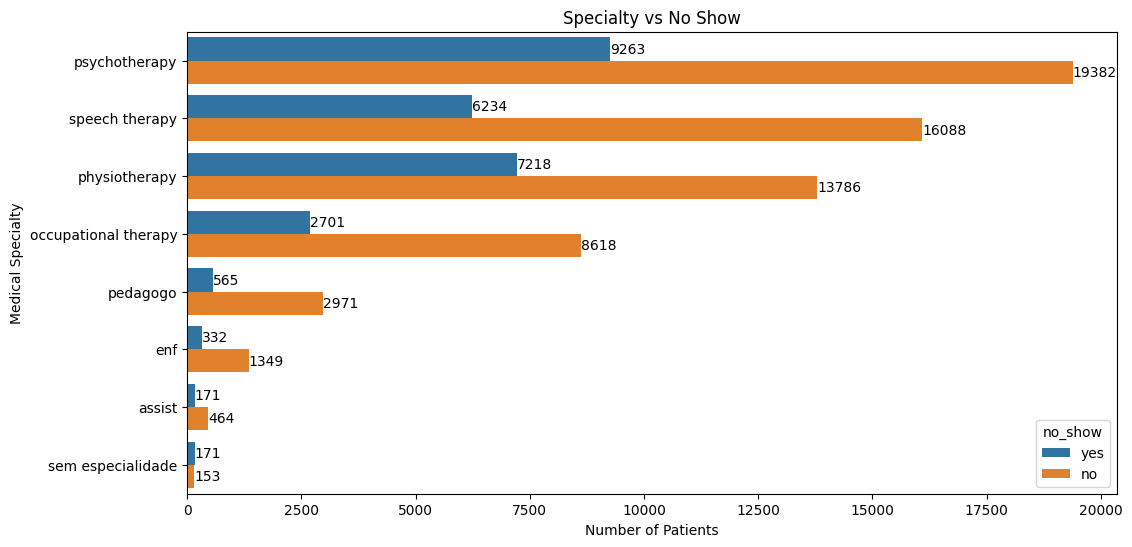

In [41]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    y="specialty",
    hue="no_show",
    order=df["specialty"].value_counts().index
)

plt.title("Specialty vs No Show")
plt.xlabel("Number of Patients")
plt.ylabel("Medical Specialty")

for container in ax.containers:
    ax.bar_label(container)

plt.show()
#Medical specialty has a noticeable relationship with appointment 
# attendance. Physiotherapy and Psychotherapy have comparatively
#  higher no-show rates among the major specialties, while Pedagogo has 
# the best attendance. The Sem Especialidade category should be 
# interpreted cautiously due to its limited number of records.

In [42]:
#Appointment Shift vs No Show
pd.crosstab(df["appointment_shift"], df["no_show"])

no_show,no,yes
appointment_shift,,
afternoon,41111,18223
morning,33650,16609


In [43]:
pd.crosstab(
    df["appointment_shift"],
    df["no_show"],
    normalize="index"
) * 100

no_show,no,yes
appointment_shift,,
afternoon,69.287424,30.712576
morning,66.953183,33.046817


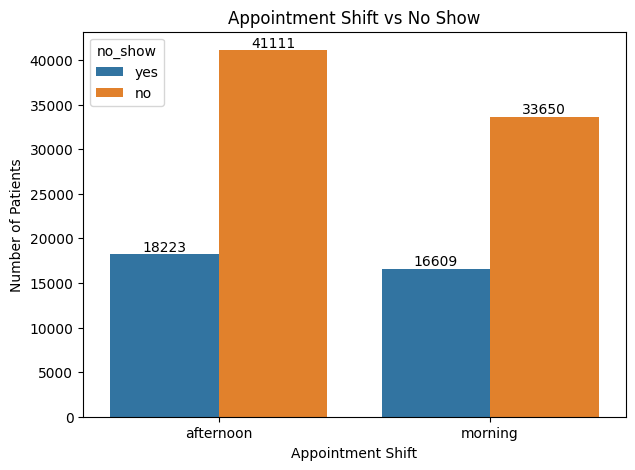

In [44]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="appointment_shift",
    hue="no_show"
)

plt.title("Appointment Shift vs No Show")
plt.xlabel("Appointment Shift")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [45]:
#The analysis indicates that appointment shift has a weak to moderate
#  relationship with appointment attendance. Morning appointments show a
#  slightly higher no-show rate (33.05%) compared to afternoon
#  appointments (30.71%). Therefore, hospitals may consider additional
#  reminder strategies or scheduling improvements for morning appointments.

In [46]:
#Medical Condition Features vs No Show
medical_features = [
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "Scholarship"
]

for feature in medical_features:
    print(f"\n{'='*50}")
    print(feature)
    print(pd.crosstab(df[feature], df["no_show"]))


Hipertension
no_show          no    yes
Hipertension              
0             70077  33150
1              4684   1682

Diabetes
no_show      no    yes
Diabetes              
0         72860  34108
1          1901    724

Alcoholism
no_show        no    yes
Alcoholism              
0           73303  34258
1            1458    574

Handcap
no_show     no    yes
Handcap              
0        74069  34525
1          692    307

Scholarship
no_show         no    yes
Scholarship              
0            70639  32914
1             4122   1918


In [47]:
for feature in medical_features:
    print(f"\n{'='*50}")
    print(feature)
    print(pd.crosstab(
        df[feature],
        df["no_show"],
        normalize="index"
    )*100)


Hipertension
no_show              no        yes
Hipertension                      
0             67.886309  32.113691
1             73.578385  26.421615

Diabetes
no_show          no        yes
Diabetes                      
0         68.113828  31.886172
1         72.419048  27.580952

Alcoholism
no_show            no        yes
Alcoholism                      
0           68.150166  31.849834
1           71.751969  28.248031

Handcap
no_show         no        yes
Handcap                      
0        68.207267  31.792733
1        69.269269  30.730731

Scholarship
no_show             no        yes
Scholarship                      
0            68.215310  31.784690
1            68.245033  31.754967


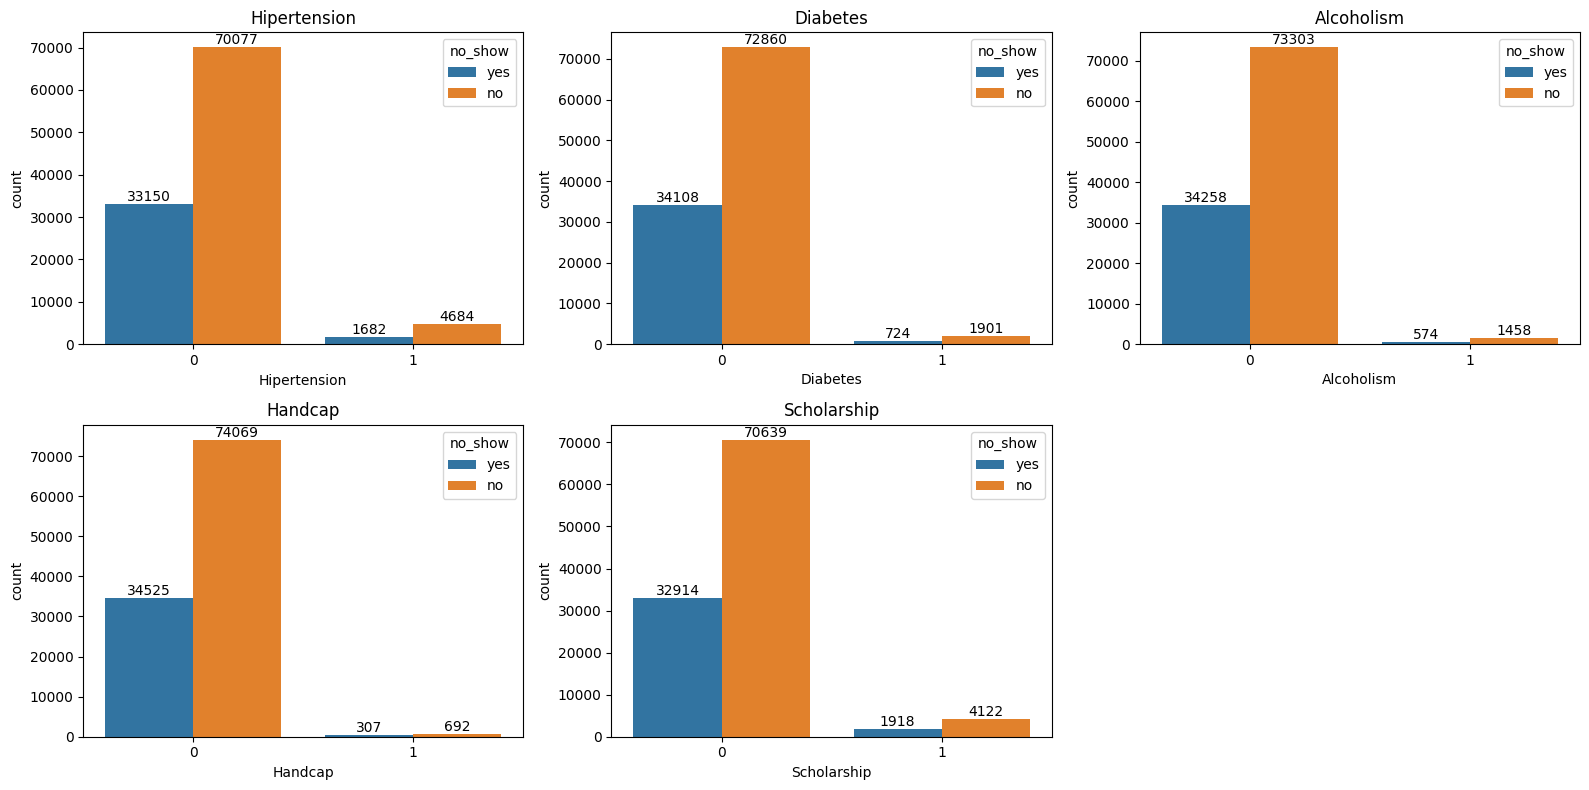

In [48]:
medical_features = [
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "Scholarship"
]

fig, axes = plt.subplots(2,3, figsize=(16,8))
axes = axes.flatten()

for i, feature in enumerate(medical_features):

    ax = sns.countplot(
        data=df,
        x=feature,
        hue="no_show",
        ax=axes[i]
    )

    axes[i].set_title(feature)

    for container in ax.containers:
        ax.bar_label(container)

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [49]:
#Hipertension shows a relationship with appointment attendance. 
# Patients with hypertension are less likely to miss their appointments.

#Diabetes has a moderate relationship with appointment attendance.
#  Diabetic patients tend to miss fewer appointments.

#Alcoholism shows a small relationship with appointment attendance, 
# but the limited sample size means it should not be considered a 
# strong predictor on its own.

#Handcap does not appear to be a strong standalone predictor of
#  appointment attendance due to the small sample size

#Scholarship has little to no relationship with appointment attendance
# . It is likely to be a weak predictor for the machine learning model.

In [50]:
#Handeling missing value 
#numerical value filling median 
num_cols = [
    "age",
    "average_temp_day",
    "average_rain_day",
    "max_temp_day",
    "max_rain_day"
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [51]:
#categorical value with mode
cat_cols = [
    "specialty",
    "disability",
    "place"
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [52]:
df.isnull().sum()

specialty                      0
appointment_time               0
gender                         0
no_show                        0
disability                     0
place                          0
appointment_shift              0
age                            0
under_12_years_old             0
over_60_years_old              0
patient_needs_companion        0
average_temp_day               0
average_rain_day               0
max_temp_day                   0
max_rain_day                   0
rainy_day_before               0
storm_day_before               0
rain_intensity                 0
heat_intensity                 0
appointment_date_continuous    0
Hipertension                   0
Diabetes                       0
Alcoholism                     0
Handcap                        0
Scholarship                    0
SMS_received                   0
dtype: int64

In [53]:
#We had over 20% missing values in the age column. Dropping 
# those rows would have caused a significant loss of data and could
#  reduce model performance. Therefore, I used median imputation, which 
# is robust to outliers and preserves the dataset size.

In [54]:
#Feature ENgineering
df["appointment_date_continuous"] = pd.to_datetime(
    df["appointment_date_continuous"]
)

In [55]:

df["appointment_month"] = df["appointment_date_continuous"].dt.month


In [56]:
df.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,appointment_month
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,no_rain,warm,2020-01-01,0,0,0,0,0,0,1
1,psychotherapy,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,no_rain,cold,2020-01-01,0,0,0,0,0,0,1
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,no_rain,warm,2020-01-01,0,0,0,0,0,0,1
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,moderate,mild,2020-01-01,0,0,0,0,0,1,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,12.0,0,0,...,no_rain,mild,2020-01-01,0,0,0,0,0,0,1


In [57]:
df.select_dtypes(include="object").columns

Index(['specialty', 'gender', 'no_show', 'disability', 'place',
       'appointment_shift', 'rain_intensity', 'heat_intensity'],
      dtype='str')

In [58]:
print(df.columns.tolist())

['specialty', 'appointment_time', 'gender', 'no_show', 'disability', 'place', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received', 'appointment_month']


In [59]:
print(df["place"].nunique())
print(df["specialty"].nunique())


26289
8


In [60]:
#Drop place
#26,289 unique values hain.
#One-Hot Encoding se dataset bahut bada ho jayega.
#Isse model slow hoga aur overfitting ka risk badhega.
df.drop(columns="place", inplace=True)

In [61]:
#encode target variable
df["no_show"] = df["no_show"].map({
    "no": 0,
    "yes": 1
})

In [62]:
df["no_show"].value_counts()

no_show
0    74761
1    34832
Name: count, dtype: int64

In [63]:
import os
print(os.getcwd())

c:\Users\vinit\OneDrive\Desktop\coding\python\guvi\Medical_Appoinment\notebook


In [64]:
temp_df = pd.read_csv("../Data/Medical_appointment_data.csv")

df["rain_intensity"] = temp_df["rain_intensity"]

In [65]:
df["rain_intensity"].value_counts(dropna=False)

rain_intensity
no_rain     76415
moderate    16252
weak        11170
heavy        5756
Name: count, dtype: int64

In [66]:
print(df["rain_intensity"].unique())

<ArrowStringArray>
['no_rain', 'moderate', 'weak', 'heavy']
Length: 4, dtype: str


In [67]:
rain_map = {
    "no_rain": 0,
    "weak": 1,
    "moderate": 2,
    "heavy": 3
}

df["rain_intensity"] = df["rain_intensity"].map(rain_map)

In [68]:
df["rain_intensity"].value_counts(dropna=False)

rain_intensity
0    76415
2    16252
1    11170
3     5756
Name: count, dtype: int64

In [69]:
# High Intensity Coding 
print(df["heat_intensity"].unique())
print(df["heat_intensity"].value_counts(dropna=False))

<ArrowStringArray>
['warm', 'cold', 'mild', 'heavy_warm', 'heavy_cold']
Length: 5, dtype: str
heat_intensity
mild          46903
cold          30190
warm          22440
heavy_cold     8330
heavy_warm     1730
Name: count, dtype: int64


In [70]:
heat_map = {
    "cold": 0,
    "mild": 1,
    "warm": 2,
    "heavy_cold": 3,
    "heavy_warm": 4
}

df["heat_intensity"] = df["heat_intensity"].map(heat_map)

In [71]:
df["heat_intensity"].value_counts(dropna=False)
### Heat Intensity Encoding

#The `heat_intensity` feature has an inherent order
#  based on temperature severity
#  (Cold < Mild < Warm < Heavy Cold < Heavy Warm).
#  Therefore, Ordinal Encoding was applied to preserve 
# the natural ordering while converting the categorical 
# values into numerical form.

heat_intensity
1    46903
0    30190
2    22440
3     8330
4     1730
Name: count, dtype: int64

In [72]:
# gender encoding
gender_map = {
    "F": 0,
    "M": 1,
    "I": 2
}

df["gender"] = df["gender"].map(gender_map)

df["gender"].value_counts(dropna=False)

gender
1    82269
0    27077
2      247
Name: count, dtype: int64

In [73]:
shift_map = {
    "morning": 0,
    "afternoon": 1
}

df["appointment_shift"] = df["appointment_shift"].map(shift_map)

df["appointment_shift"].value_counts(dropna=False)

appointment_shift
1    59334
0    50259
Name: count, dtype: int64

In [74]:
df = pd.get_dummies(
    df,
    columns=["specialty", "disability"],
    drop_first=True,
    dtype=int
)

In [75]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   appointment_time                109593 non-null  int64         
 1   gender                          109593 non-null  int64         
 2   no_show                         109593 non-null  int64         
 3   appointment_shift               109593 non-null  int64         
 4   age                             109593 non-null  float64       
 5   under_12_years_old              109593 non-null  int64         
 6   over_60_years_old               109593 non-null  int64         
 7   patient_needs_companion         109593 non-null  int64         
 8   average_temp_day                109593 non-null  float64       
 9   average_rain_day                109593 non-null  float64       
 10  max_temp_day                    109593 non-null  float64       
 11

,appointment_time,gender,no_show,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,...,appointment_month,specialty_enf,specialty_occupational therapy,specialty_pedagogo,specialty_physiotherapy,specialty_psychotherapy,specialty_sem especialidade,specialty_speech therapy,disability_intellectual,disability_motor
0,17,0,1,1,9.0,1,0,1,23.18,0.00,...,1,0,0,0,0,1,0,0,1,0
1,7,1,0,0,11.0,1,0,1,14.31,0.02,...,1,0,0,0,0,1,0,0,1,0
2,16,1,0,1,8.0,1,0,1,21.61,0.01,...,1,0,0,0,0,0,0,1,1,0
3,14,1,1,1,9.0,1,0,1,21.39,0.11,...,1,0,0,0,0,0,0,1,1,0
4,8,1,0,0,12.0,0,0,0,20.15,0.02,...,1,0,0,0,1,0,0,0,0,1


In [76]:
df.drop(columns=["appointment_date_continuous"], inplace=True)

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   appointment_time                109593 non-null  int64  
 1   gender                          109593 non-null  int64  
 2   no_show                         109593 non-null  int64  
 3   appointment_shift               109593 non-null  int64  
 4   age                             109593 non-null  float64
 5   under_12_years_old              109593 non-null  int64  
 6   over_60_years_old               109593 non-null  int64  
 7   patient_needs_companion         109593 non-null  int64  
 8   average_temp_day                109593 non-null  float64
 9   average_rain_day                109593 non-null  float64
 10  max_temp_day                    109593 non-null  float64
 11  max_rain_day                    109593 non-null  float64
 12  rainy_day_before           

In [78]:
# MODEL BUIDING START
X = df.drop("no_show", axis=1)
y = df["no_show"]
#### Feature and Target Separation

#The dataset was divided into:
#X (Features):** All independent variables used for prediction.
#y (Target):** `no_show`, which indicates whether the patient missed the appointment.

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [80]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (87674, 31)
X_test : (21919, 31)
y_train: (87674,)
y_test : (21919,)


## Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data. The `random_state=42` parameter ensures reproducible results, and `stratify=y` preserves the class distribution of the target variable (`no_show`) in both training and testing datasets.

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [82]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(87674, 31)
(21919, 31)


In [83]:
# model 1 - Logistic Regression 
#We selected Logistic Regression as the baseline model
#  because our target variable (no_show) is binary 
# with two classes (0 and 1). Logistic Regression is
#  specifically designed for binary classification, 
# is computationally efficient, predicts probabilities, 
# and provides a good benchmark before trying more complex models
#  such as Decision Tree or Random Forest.

In [84]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [85]:
lr.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [86]:
#PREDICTION
y_pred = lr.predict(X_test_scaled)

In [87]:
print(y_pred[:10])

[0 0 0 0 0 0 0 0 1 0]


In [88]:
#Model Evaluation
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6920023723710024


In [89]:
## Accuracy

#The Logistic Regression model achieved an accuracy of **69.20%**,
#  which means it correctly classified approximately 69 out of
#  every 100 patients in the test dataset.

#However, since the dataset is moderately imbalanced 
# (more patients attended than missed appointments),
#  accuracy alone is not sufficient to evaluate the model.
#  Therefore, additional metrics such as Precision, Recall,
#  F1-Score, and the Confusion Matrix are also analyzed.

In [90]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)
## Confusion Matrix

#The confusion matrix summarizes the model's prediction performance.
# True Negatives (TN): 14,282 patients who attended were correctly
#  predicted as attended.

# False Positives (FP): 670 patients who attended were
#  incorrectly predicted as no-show.

# False Negatives (FN): 6,081 patients who missed their
#  appointments were incorrectly predicted as attended.

# True Positives (TP): 886 patients who missed their
#  appointments were correctly predicted as no-show.

#The model performs well in identifying patients who attend
#  appointments but struggles to correctly identify patients who
#  miss appointments.

[[14282   670]
 [ 6081   886]]


In [91]:
#precision
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.5694087403598972


In [92]:
## Precision

#The Logistic Regression model achieved a precision of **56.94%**.

#This means that among all patients predicted as **No Show**,
#  approximately **57% actually missed their appointments**,
#  while the remaining predictions were false positives.

#Precision indicates how reliable the positive predictions made by
#  the model are.

In [93]:
#Recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)
## Recall

#The Logistic Regression model achieved a recall of **12.72%**.

#This means the model correctly identified only about **13 out
#  of every 100 patients who actually missed their appointments**.
#  The remaining patients were incorrectly classified as 
# attending (False Negatives).

#The low recall indicates that the model struggles 
# to detect patients who are likely to miss their appointments.

Recall: 0.1271709487584326


In [94]:
#F1 Score
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.20790801361023115


In [95]:
# F1-Score

#The Logistic Regression model achieved an **F1-Score of 20.79%**.

#The F1-Score is the harmonic mean of Precision and Recall.
#  It provides a balanced evaluation of the model, especially
#  when dealing with imbalanced datasets.

#The low F1-Score indicates that the model struggles to balance 
# correct positive predictions and the identification of actual
#  no-show patients.

The Logistic Regression model achieved a moderate accuracy of 69.20%, but its Recall (12.72%) and F1-Score (20.79%) are very low. This indicates that the model fails to identify most patients who actually miss their appointments. Therefore, Logistic Regression is not the best model for this problem, and more powerful models such as Decision Tree and Random Forest should be evaluated.

In [96]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.96      0.81     14952
           1       0.57      0.13      0.21      6967

    accuracy                           0.69     21919
   macro avg       0.64      0.54      0.51     21919
weighted avg       0.66      0.69      0.62     21919



In [97]:
#Model 2- Decision Tree Classifie
from sklearn.tree import DecisionTreeClassifier

In [98]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [99]:
dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [100]:
y_pred_dt = dt.predict(X_test)
## Decision Tree Classifier

#A Decision Tree Classifier was trained on the original 
# (unscaled) training dataset. Unlike Logistic Regression,
#  Decision Trees do not require feature scaling because
#  they split the data based on feature values rather than 
# distances. The trained model was then used to predict 
# appointment attendance on the test dataset.

In [101]:
#Evaluation
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

## Decision Tree Accuracy

#The accuracy of the Decision Tree model was calculated
#  to measure the percentage of correctly classified 
# patient appointments.

Decision Tree Accuracy: 0.6667731192116428


In [102]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[11332  3620]
 [ 3684  3283]]


In [103]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.75      0.76      0.76     14952
           1       0.48      0.47      0.47      6967

    accuracy                           0.67     21919
   macro avg       0.62      0.61      0.61     21919
weighted avg       0.67      0.67      0.67     21919



## Decision Tree Performance

The Decision Tree model achieved an accuracy of **66.68%**.

Although its overall accuracy is slightly lower than Logistic Regression, it significantly improved the Recall for the no-show class from **12.72%** to **47.12%**. This indicates that the Decision Tree is much better at identifying patients who are likely to miss their appointments.

Since the primary objective of this project is to predict no-show patients, the Decision Tree performs better than Logistic Regression despite its slightly lower accuracy.

In [104]:
#Model 3 - Random Forest 
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [105]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [106]:
## Random Forest Classifier

#A Random Forest Classifier was trained using the original
#  training dataset. Random Forest is an ensemble learning 
# algorithm that combines predictions from multiple
#  Decision Trees using majority voting. 
# This approach improves generalization and reduces
#  overfitting compared to a single Decision Tree.

In [107]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7105707377161367


In [108]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[13168  1784]
 [ 4560  2407]]


In [109]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.74      0.88      0.81     14952
           1       0.57      0.35      0.43      6967

    accuracy                           0.71     21919
   macro avg       0.66      0.61      0.62     21919
weighted avg       0.69      0.71      0.69     21919



## Model Comparison

Three machine learning models were evaluated for predicting patient no-shows.

- Logistic Regression achieved an accuracy of 69.20% but had a very low Recall (12.72%), making it ineffective at identifying patients who miss appointments.
- Decision Tree significantly improved Recall (47.12%) and F1-Score (47.34%), although its overall accuracy decreased to 66.68%.
- Random Forest achieved the highest Accuracy (71.06%) while maintaining good Precision (57.44%) and a considerably better Recall (34.55%) than Logistic Regression.

Overall, Random Forest provided the most balanced performance and was selected as the final model for this project.

In [110]:
#: Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                           Feature  Importance
7                 average_temp_day    0.176729
9                     max_temp_day    0.146346
3                              age    0.103051
21               appointment_month    0.096913
10                    max_rain_day    0.087002
0                 appointment_time    0.084320
8                 average_rain_day    0.079096
20                    SMS_received    0.024407
14                  heat_intensity    0.023841
1                           gender    0.020146
13                  rain_intensity    0.016221
2                appointment_shift    0.014297
30                disability_motor    0.011028
26         specialty_psychotherapy    0.011004
29         disability_intellectual    0.010844
19                     Scholarship    0.009941
28        specialty_speech therapy    0.009810
25         specialty_physiotherapy    0.009381
6          patient_needs_companion    0.009197
4               under_12_years_old    0.008432
11           

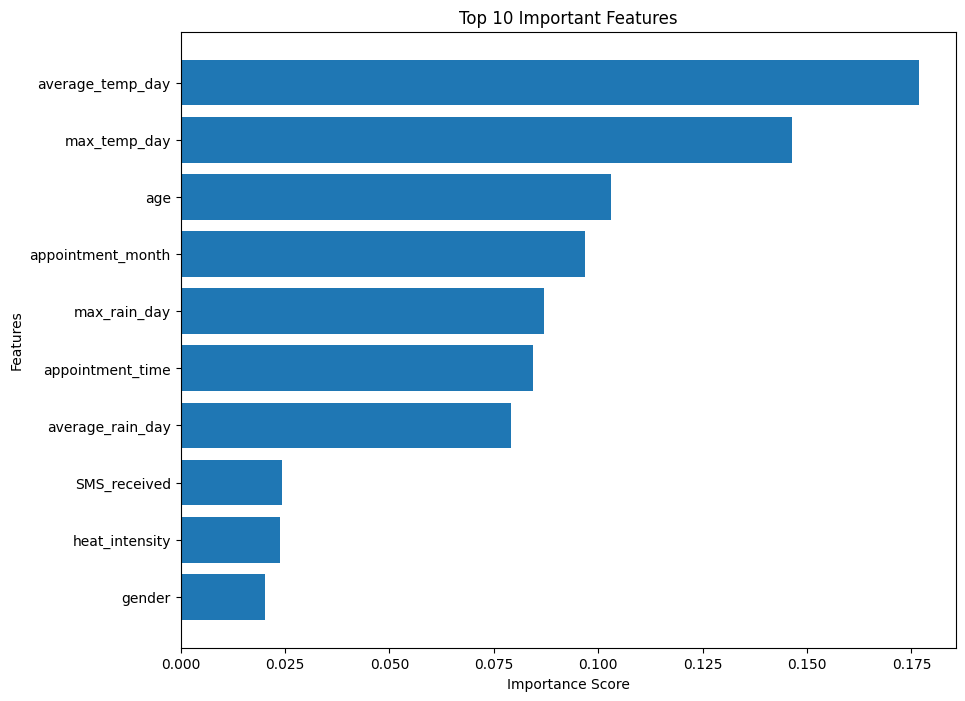

In [111]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

### Feature Importance

Feature importance analysis was performed using the Random Forest model to identify the variables that had the greatest influence on predicting patient no-shows.

The analysis showed that weather-related variables such as **average temperature**, **maximum temperature**, and **maximum rainfall** were among the most influential features. Patient **age**, **appointment month**, and **appointment time** also played significant roles. In comparison, features such as **gender** and **SMS received** had relatively lower importance.

This analysis helps understand which factors contributed the most to the model's predictions.

AUC Score: 0.7489028380603108


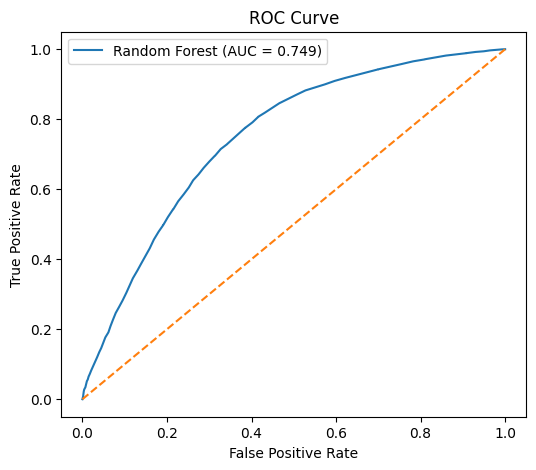

In [112]:
#ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability prediction
y_prob = rf.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
#ROC Curve was used to evaluate the model's ability to
#  distinguish between patients who attended and
#  those who missed their appointments. The AUC score
#  summarizes this performance, with values closer to 1 
# indicating better discrimination.

### ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) Curve was used to evaluate the classification performance of the Random Forest model.

The model achieved an **AUC score of 0.749**, indicating good discrimination between patients who attended their appointments and those who missed them.

Since the ROC curve lies well above the diagonal reference line, the model performs significantly better than random guessing.

In [113]:
#Cross Validation 
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.71139194 0.71157443 0.71152881 0.70727256 0.70823068]
Mean Accuracy: 0.7099996852341743


### Cross Validation

To evaluate the stability of the Random Forest model, 5-fold Cross Validation was performed.

The model achieved a mean accuracy of **71.0%**, with all folds producing similar results. This indicates that the model generalizes well and is not significantly overfitted to a particular train-test split.

# Conclusion

The objective of this project was to analyze the factors influencing patient no-shows and develop a machine learning model to predict whether a patient would miss a scheduled medical appointment.

During data preprocessing, missing values were handled, irrelevant features were removed, categorical variables were encoded, and new features such as appointment month were created to improve model performance.

Exploratory Data Analysis (EDA) revealed several important insights. Younger patients had a slightly higher tendency to miss appointments. Afternoon appointments showed a marginally higher no-show rate than morning appointments. Medical conditions such as hypertension, diabetes, alcoholism, and handicap had only a limited impact on appointment attendance. Weather-related variables and appointment timing appeared to have a stronger influence on patient behavior.

Three machine learning models were developed and compared:
- Logistic Regression
- Decision Tree
- Random Forest

Among these, the Random Forest model achieved the best overall performance with:
- Accuracy: **71.06%**
- Precision: **57.44%**
- Recall: **34.55%**
- F1-Score: **43.16%**
- AUC Score: **0.749**

The model also achieved an average Cross Validation Accuracy of **71.00%**, indicating stable and reliable performance across different data splits.

Feature Importance analysis showed that weather-related variables (average temperature, maximum temperature, rainfall), patient age, appointment month, and appointment time were the most influential factors in predicting patient no-shows.

Overall, the Random Forest model provided the best balance between accuracy and classification performance. This predictive model can help healthcare organizations identify patients who are at higher risk of missing appointments, enabling hospitals to send reminders, improve appointment scheduling, optimize resource utilization, and reduce operational losses caused by no-shows.

In [114]:
import os

os.makedirs("../Data", exist_ok=True)

df.to_csv("../Data/cleaned_medical_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [115]:
import joblib
import os

os.makedirs("../model", exist_ok=True)

joblib.dump(rf, "../model/random_forest_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [116]:
print(X_train.columns.tolist())

['appointment_time', 'gender', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received', 'appointment_month', 'specialty_enf', 'specialty_occupational therapy', 'specialty_pedagogo', 'specialty_physiotherapy', 'specialty_psychotherapy', 'specialty_sem especialidade', 'specialty_speech therapy', 'disability_intellectual', 'disability_motor']


In [117]:
# Lets begin DEMAND FORCASTING 

# Damand dataset
import pandas as pd

original_df = pd.read_csv("../data/Medical_appointment_data.csv")

print(original_df.columns.tolist())

['specialty', 'appointment_time', 'gender', 'no_show', 'disability', 'place', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received']


In [118]:
import pandas as pd

forecast_df = pd.read_csv(
    "../data/Medical_appointment_data.csv",
    parse_dates=["appointment_date_continuous"]
)

forecast_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   specialty                    89466 non-null   str           
 1   appointment_time             109593 non-null  int64         
 2   gender                       109593 non-null  str           
 3   no_show                      109593 non-null  str           
 4   disability                   92992 non-null   str           
 5   place                        98054 non-null   str           
 6   appointment_shift            109593 non-null  str           
 7   age                          86633 non-null   float64       
 8   under_12_years_old           109593 non-null  int64         
 9   over_60_years_old            109593 non-null  int64         
 10  patient_needs_companion      109593 non-null  int64         
 11  average_temp_day             107382 n

In [119]:
daily_df = (
    forecast_df
    .groupby("appointment_date_continuous")
    .size()
    .reset_index(name="appointments")
)

daily_df.head()

,appointment_date_continuous,appointments
0,2020-01-01,25
1,2020-01-02,33
2,2020-01-03,18
3,2020-01-04,16
4,2020-01-05,15


In [120]:
print(daily_df.info())
print(daily_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   appointment_date_continuous  498 non-null    datetime64[us]
 1   appointments                 498 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 7.9 KB
None
      appointment_date_continuous  appointments
count                         498    498.000000
mean          2020-09-05 12:00:00    220.066265
min           2020-01-01 00:00:00      1.000000
25%           2020-05-04 06:00:00     10.000000
50%           2020-09-05 12:00:00    126.500000
75%           2021-01-07 18:00:00    393.250000
max           2021-05-12 00:00:00   1512.000000
std                           NaN    245.803633


In [121]:
print(daily_df.head())

  appointment_date_continuous  appointments
0                  2020-01-01            25
1                  2020-01-02            33
2                  2020-01-03            18
3                  2020-01-04            16
4                  2020-01-05            15


In [122]:
train_size = int(len(daily_df) * 0.8)

train = daily_df.iloc[:train_size]

test = daily_df.iloc[train_size:]

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

Train Shape: (398, 2)
Test Shape : (100, 2)


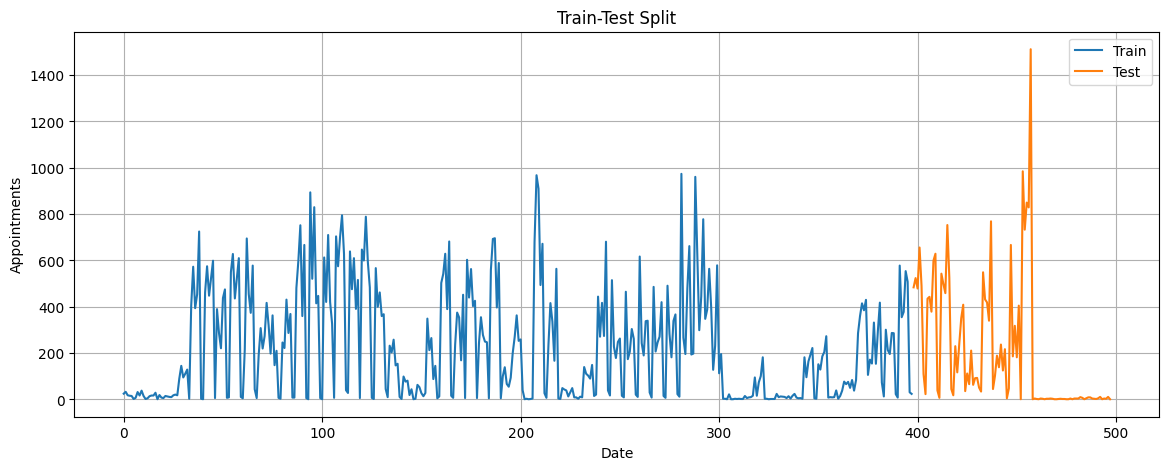

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(train.index, train["appointments"], label="Train")

plt.plot(test.index, test["appointments"], label="Test")

plt.title("Train-Test Split")

plt.xlabel("Date")

plt.ylabel("Appointments")

plt.legend()

plt.grid(True)

plt.show()

In [124]:
print(daily_df["appointments"].describe())

count     498.000000
mean      220.066265
std       245.803633
min         1.000000
25%        10.000000
50%       126.500000
75%       393.250000
max      1512.000000
Name: appointments, dtype: float64


In [125]:
print(daily_df["appointments"].describe())

count     498.000000
mean      220.066265
std       245.803633
min         1.000000
25%        10.000000
50%       126.500000
75%       393.250000
max      1512.000000
Name: appointments, dtype: float64


In [126]:
print(daily_df.head(15))
print(daily_df.tail(15))

   appointment_date_continuous  appointments
0                   2020-01-01            25
1                   2020-01-02            33
2                   2020-01-03            18
3                   2020-01-04            16
4                   2020-01-05            15
5                   2020-01-06             2
6                   2020-01-07             7
7                   2020-01-08            32
8                   2020-01-09            17
9                   2020-01-10            38
10                  2020-01-11            15
11                  2020-01-12             2
12                  2020-01-13             5
13                  2020-01-14            14
14                  2020-01-15            17
    appointment_date_continuous  appointments
483                  2021-04-28             7
484                  2021-04-29             1
485                  2021-04-30             5
486                  2021-05-01             9
487                  2021-05-02             9
488 

In [127]:
import statsmodels

print(statsmodels.__version__)

0.14.6


In [128]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_df["appointments"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] <= 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

ADF Statistic: -3.6282673705348887
p-value: 0.00524305186519189
Stationary


In [129]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA Model
arima_model = ARIMA(train["appointments"], order=(1, 0, 1))

# Train Model
arima_fit = arima_model.fit()

# Model Summary
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           appointments   No. Observations:                  398
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2681.355
Date:                Sun, 19 Jul 2026   AIC                           5370.710
Time:                        19:17:42   BIC                           5386.656
Sample:                             0   HQIC                          5377.026
                                - 398                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        223.2533     38.547      5.792      0.000     147.703     298.803
ar.L1          0.7674      0.069     11.187      0.000       0.633       0.902
ma.L1         -0.4025      0.075     -5.337      0.0

In [130]:
forecast = arima_fit.forecast(steps=len(test))

print(forecast.head())

398    149.356925
399    166.542068
400    179.730681
401    189.852187
402    197.619864
Name: predicted_mean, dtype: float64


In [131]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(test["appointments"], forecast)

rmse = np.sqrt(
    mean_squared_error(
        test["appointments"],
        forecast
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 234.95174456547284
RMSE: 287.4465182946645


In [134]:
import pandas as pd

# Save Forecast Results
forecast_df = pd.DataFrame({
    "Actual": test["appointments"].values,
    "Forecast": forecast.values
})

forecast_df.to_csv(
    "../data/arima_forecast.csv",
    index=False
)

# Save Metrics
metrics_df = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "ADF Statistic",
        "P-value"
    ],
    "Value": [
        mae,
        rmse,
        result[0],
        result[1]
    ]
})

metrics_df.to_csv(
    "../data/arima_metrics.csv",
    index=False
)

print("✅ ARIMA files saved successfully!")

✅ ARIMA files saved successfully!


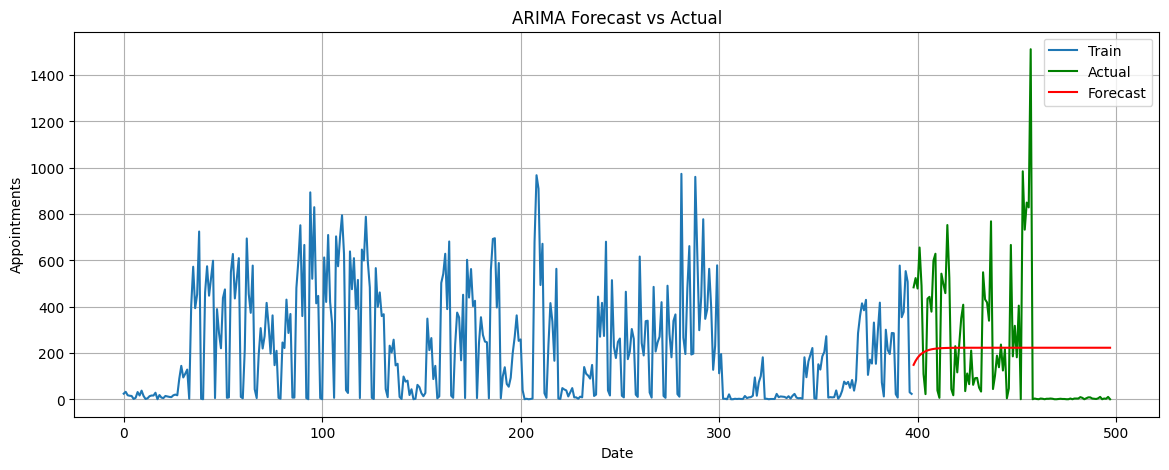

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    train.index,
    train["appointments"],
    label="Train"
)

plt.plot(
    test.index,
    test["appointments"],
    label="Actual",
    color="green"
)

plt.plot(
    test.index,
    forecast,
    label="Forecast",
    color="red"
)

plt.title("ARIMA Forecast vs Actual")

plt.xlabel("Date")

plt.ylabel("Appointments")

plt.legend()

plt.grid(True)

plt.show()

An ARIMA(1,0,1) model was developed to forecast future appointment demand. The time series was first checked for stationarity using the Augmented Dickey-Fuller (ADF) Test, which confirmed stationarity (p-value = 0.0052). The model achieved a Mean Absolute Error (MAE) of approximately 234.95 and a Root Mean Squared Error (RMSE) of approximately 287.45. While the model successfully captured the overall average demand, it struggled to predict sudden spikes because of the highly irregular appointment patterns in the dataset.

In [133]:
print(X_train.columns.tolist())

['appointment_time', 'gender', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received', 'appointment_month', 'specialty_enf', 'specialty_occupational therapy', 'specialty_pedagogo', 'specialty_physiotherapy', 'specialty_psychotherapy', 'specialty_sem especialidade', 'specialty_speech therapy', 'disability_intellectual', 'disability_motor']


In [140]:
print(forecast_df.columns)

Index(['Date', 'Actual', 'Forecast'], dtype='str')


In [139]:
forecast_df = pd.DataFrame({
    "Date": test.index,
    "Actual": test["appointments"].values,
    "Forecast": forecast.values
})

forecast_df.to_csv("../data/arima_forecast.csv", index=False)

In [142]:
print(forecast_df.columns)

Index(['Date', 'Actual', 'Forecast'], dtype='str')


In [143]:
print(metrics_df.columns)

Index(['Metric', 'Value'], dtype='str')
